In [1]:
!pip install ultralytics

In [1]:
import os
import numpy as np
import cv2
import torch
import pandas as pd
from glob import glob
from ultralytics import YOLO
from radiomics import featureextractor
import SimpleITK as sitk

# تحميل نموذج YOLO
model = YOLO(r'F:\new\best (3).pt')
model.to('cpu')  # استخدام المعالج لتقليل استهلاك الذاكرة

# تحميل جميع الصور من المسار
root_path = r'F:\new\archive (1)\alldata\*.*'
images_data = glob(root_path)
print(f"📂 Found {len(images_data)} images.")

# إنشاء كائن استخراج الميزات الشعاعية مرة واحدة
extractor = featureextractor.RadiomicsFeatureExtractor()
feature_list = []  # لتجميع كل الميزات

# بدء المعالجة
for idx, img_path in enumerate(images_data):
    image = cv2.imread(img_path)
    if image is None:
        print(f"❌ Skipping unreadable image: {img_path}")
        continue

    results = model(image)
    found_stones = False

    for result in results:
        for box in result.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            confidence = float(box.conf[0])

            if confidence > 0.5:
                found_stones = True

                # إنشاء ROI
                mask_roi = np.zeros_like(image[:, :, 0], dtype=np.uint8)
                mask_roi[y1:y2, x1:x2] = 1
                roi = image.copy()
                roi[mask_roi == 0] = 0

                # تحويل إلى صور SimpleITK
                roi_sitk = sitk.GetImageFromArray(cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY))
                mask_sitk = sitk.GetImageFromArray(mask_roi)

                try:
                    features = extractor.execute(roi_sitk, mask_sitk)
                    feature_dict = {'Image_Name': os.path.basename(img_path) + '_ROI'}
                    for key, value in features.items():
                        if "original" in key:
                            feature_dict[key] = value
                    feature_list.append(feature_dict)
                except Exception as e:
                    print(f"⚠️ Radiomics extraction failed for {img_path}: {e}")

    if not found_stones:
        print(f"⚠️ No stones detected in image: {os.path.basename(img_path)}")

# حفظ الميزات في CSV
if feature_list:
    df = pd.DataFrame(feature_list)
    csv_path = 'C:\Users\DELL\Downloads\radiomics_features.csv'
    df.to_csv(csv_path, index=False)
    print(f"✅ Radiomic features saved to: {csv_path}")
else:
    print("❌ No features extracted. CSV not created.")


📂 Found 1299 images.

0: 544x640 1 Tas_Var, 2251.0ms
Speed: 270.9ms preprocess, 2251.0ms inference, 295.9ms postprocess per image at shape (1, 3, 544, 640)


Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated



0: 544x640 1 Tas_Var, 985.1ms
Speed: 13.8ms preprocess, 985.1ms inference, 1.1ms postprocess per image at shape (1, 3, 544, 640)


Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated



0: 544x640 2 Tas_Vars, 948.2ms
Speed: 4.4ms preprocess, 948.2ms inference, 39.1ms postprocess per image at shape (1, 3, 544, 640)


...


0: 544x640 7 Tas_Vars, 1294.5ms
Speed: 4.5ms preprocess, 1294.5ms inference, 3.9ms postprocess per image at shape (1, 3, 544, 640)


Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated



0: 544x640 6 Tas_Vars, 1369.6ms
Speed: 5.2ms preprocess, 1369.6ms inference, 1.9ms postprocess per image at shape (1, 3, 544, 640)


Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
Shape features are only available 3D input (for 2D input, use shape2D). Found 2D input
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated


✅ Radiomic features saved to: radiomics_features.csv


In [2]:
import os
import numpy as np
import cv2
import torch
import pandas as pd
from glob import glob
from ultralytics import YOLO
from radiomics import featureextractor
import SimpleITK as sitk

In [3]:
csv_path =r'C:\Users\DELL\Downloads\radiomics_features.csv'
df=pd.read_csv(csv_path)

In [4]:
df=df.loc[:,~ df.columns.str.startswith('diagnostics_')]

In [6]:

df


,Image_Name,original_firstorder_10Percentile,original_firstorder_90Percentile,original_firstorder_Energy,original_firstorder_Entropy,original_firstorder_InterquartileRange,original_firstorder_Kurtosis,original_firstorder_Maximum,original_firstorder_MeanAbsoluteDeviation,original_firstorder_Mean,...,original_glszm_SmallAreaHighGrayLevelEmphasis,original_glszm_SmallAreaLowGrayLevelEmphasis,original_glszm_ZoneEntropy,original_glszm_ZonePercentage,original_glszm_ZoneVariance,original_ngtdm_Busyness,original_ngtdm_Coarseness,original_ngtdm_Complexity,original_ngtdm_Contrast,original_ngtdm_Strength
0,1-3-46-670589-33-1-63700700749865510700001-506...,87.0,249.0,10303275.0,2.537944,75.00,2.650146,255.0,47.876751,135.597895,...,10.328224,0.025069,4.736216,0.077895,745.108839,0.987514,0.039081,9.653885,0.042905,1.863607
1,1-3-46-670589-33-1-63700700749865510700001-506...,89.6,249.0,9981205.0,2.567928,79.00,2.434685,255.0,48.795752,139.723112,...,6.391077,0.069308,4.363826,0.082380,760.008488,1.653586,0.046283,7.353731,0.051056,1.763182
2,1-3-46-670589-33-1-63700700750059521800001-507...,90.0,252.0,19601517.0,2.297266,103.00,2.118077,255.0,56.303380,141.491379,...,9.812860,0.094884,4.606791,0.099754,1323.579637,2.425242,0.016516,10.566587,0.079974,0.855728
3,1-3-46-670589-33-1-63700700750059521800001-507...,99.0,185.1,2194840.0,1.874925,21.75,5.848247,254.0,25.425562,124.892308,...,8.368506,0.135558,3.969816,0.130769,349.875433,0.547518,0.093922,9.750173,0.025403,4.146503
4,1-3-46-670589-33-1-63700700750059521800001-507...,90.9,253.0,19880627.0,2.286112,99.00,2.222455,255.0,55.358390,139.994048,...,15.877886,0.048220,4.725273,0.083333,1786.685714,1.533658,0.015901,12.366370,0.061168,0.971283
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1979,1-3-46-670589-33-1-63743799049969007000001-484...,101.9,229.0,2133511.0,2.451043,70.50,2.480278,255.0,42.205185,145.766667,...,8.118279,0.071621,4.106603,0.233333,40.775510,0.507365,0.107900,12.854675,0.069116,3.837635
1980,1-3-46-670589-33-1-63743799049969007000001-484...,69.2,247.2,2068779.0,2.983332,144.00,1.516418,253.0,62.752235,148.324675,...,14.405659,0.042668,4.074876,0.337662,8.883136,0.313821,0.109537,27.294172,0.190407,4.172492
1981,1-3-46-670589-33-1-63743799049969007000001-484...,40.0,230.0,1114099.0,3.243484,115.75,1.853097,255.0,62.687500,121.875000,...,26.116076,0.026264,4.093069,0.500000,2.000000,0.127930,0.213740,33.176343,0.114507,9.737339
1982,1-3-46-670589-33-1-63743799049969007000001-484...,93.9,163.2,483504.0,2.115270,38.75,2.570445,192.0,24.471111,123.533333,...,2.743968,0.029353,2.807355,0.233333,11.918367,0.501215,0.311742,4.191760,0.066741,2.293829


In [7]:
print(df.shape)


(1984, 94)


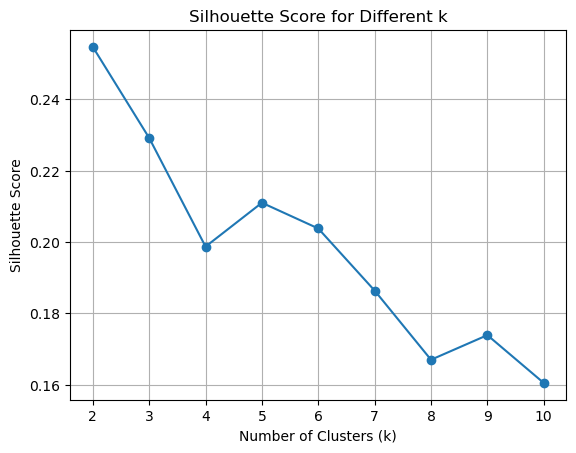

✅ سيتم استخدام عدد المجموعات: 2
💾 تم حفظ الموديل والمقياس بنجاح (kmeans_model.pkl , scaler.pkl)
1    1092
0     892
Name: Cluster, dtype: int64


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import pickle

# ✅ إزالة الأعمدة غير المفيدة
df = df.loc[:, ~df.columns.str.startswith('diagnostics_')]
df = df.drop(columns=['Image_Name'], errors='ignore')

# ✅ تنظيف البيانات (الإبقاء فقط على الأعمدة الرقمية)
df_clean = df.select_dtypes(include=['float64', 'int64']).dropna()

# ✅ توحيد القيم (Normalization)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_clean)

# ✅ تجربة عدة قيم لـ k واختيار الأفضل بناءً على Silhouette Score
scores = []
k_range = range(2, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(scaled_data)
    score = silhouette_score(scaled_data, labels)
    scores.append(score)

# ✅ رسم النتائج
plt.plot(k_range, scores, marker='o')
plt.title('Silhouette Score for Different k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

# ✅ أفضل عدد من الكلاسترز (لكن انت عايز تستخدم 2 فقط)
best_k = 2  # 🔒 تثبيت الكلاستر على 2 زي ما طلبت
print(f"✅ سيتم استخدام عدد المجموعات: {best_k}")

# ✅ تدريب النموذج النهائي باستخدام k=2
final_kmeans = KMeans(n_clusters=best_k, random_state=42)
cluster_labels = final_kmeans.fit_predict(scaled_data)

# ✅ إضافة النتائج للـ DataFrame الأصلي
df['Cluster'] = cluster_labels

# ✅ حفظ الموديل والـ scaler باستخدام pickle
with open(r"C:\Users\DELL\Downloads\kmeans_model.pkl", "wb") as f:
    pickle.dump(final_kmeans, f)

with open(r"C:\Users\DELL\Downloads\scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("💾 تم حفظ الموديل والمقياس بنجاح (kmeans_model.pkl , scaler.pkl)")
print(df['Cluster'].value_counts())


C:\Users\DELL\AppData\Local\Temp\ipykernel_10164\3096482544.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='viridis')


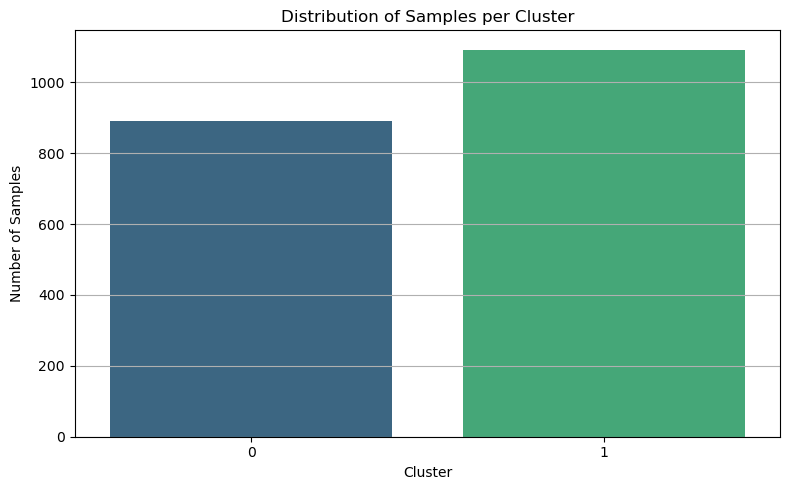

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# تحميل البيانات
# df = pd.read_csv('/content/Radiomics_with_clusters.csv')  # ← غيّر المسار حسب مكان الملف

# حساب توزيع عدد العينات في كل Cluster
cluster_counts = df['Cluster'].value_counts().sort_index()

# رسم توزيع الكلاسترز
plt.figure(figsize=(8, 5))
sns.barplot(x=cluster_counts.index, y=cluster_counts.values, palette='viridis')
plt.title('Distribution of Samples per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Samples')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


In [20]:
print(df.columns)


Index(['original_firstorder_10Percentile', 'original_firstorder_90Percentile',
       'original_firstorder_Energy', 'original_firstorder_Entropy',
       'original_firstorder_InterquartileRange',
       'original_firstorder_Kurtosis', 'original_firstorder_Maximum',
       'original_firstorder_MeanAbsoluteDeviation', 'original_firstorder_Mean',
       'original_firstorder_Median', 'original_firstorder_Minimum',
       'original_firstorder_Range',
       'original_firstorder_RobustMeanAbsoluteDeviation',
       'original_firstorder_RootMeanSquared', 'original_firstorder_Skewness',
       'original_firstorder_TotalEnergy', 'original_firstorder_Uniformity',
       'original_firstorder_Variance', 'original_glcm_Autocorrelation',
       'original_glcm_ClusterProminence', 'original_glcm_ClusterShade',
       'original_glcm_ClusterTendency', 'original_glcm_Contrast',
       'original_glcm_Correlation', 'original_glcm_DifferenceAverage',
       'original_glcm_DifferenceEntropy', 'original_glcm_

عرض أعلى 15 خاصية اختلافًا بين الكلاسترين

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# 🔍 فصل الكلاسترين
cluster_0 = df[df['Cluster'] == 0]
cluster_1 = df[df['Cluster'] == 1]

# 📊 مقارنة المتوسطات بين الكلاسترين
mean_comparison = pd.DataFrame({
    "Cluster 0 Mean": cluster_0.mean(numeric_only=True),
    "Cluster 1 Mean": cluster_1.mean(numeric_only=True),
    "Difference (0 - 1)": cluster_0.mean(numeric_only=True) - cluster_1.mean(numeric_only=True)
})

# 📌 ترتيب حسب الفرق الأكبر
mean_comparison["Abs Diff"] = mean_comparison["Difference (0 - 1)"].abs()
mean_comparison_sorted = mean_comparison.sort_values(by="Abs Diff", ascending=False)

# 🔝 عرض أعلى 15 خاصية اختلافًا بين الكلاسترين
print(mean_comparison_sorted.head(15))


                                                    Cluster 0 Mean  \
original_firstorder_Energy                            2.082160e+06   
original_firstorder_TotalEnergy                       2.082160e+06   
original_glszm_LargeAreaHighGrayLevelEmphasis         9.977995e+02   
original_firstorder_Variance                          2.129702e+03   
original_glcm_ClusterProminence                       4.714416e+02   
original_gldm_LargeDependenceHighGrayLevelEmphasis    2.083464e+02   
original_glszm_LargeAreaEmphasis                      1.193629e+02   
original_glszm_ZoneVariance                           8.261769e+01   
original_glrlm_LongRunHighGrayLevelEmphasis           4.978719e+01   
original_gldm_GrayLevelNonUniformity                  2.398358e+01   
original_glrlm_RunLengthNonUniformity                 3.288555e+01   
original_gldm_DependenceNonUniformity                 1.835893e+01   
original_firstorder_InterquartileRange                5.824664e+01   
original_firstorder_

 الخصائص اللي لقينا فيها فرق كبير رسم المتوسط ليها####

<Figure size 1400x800 with 0 Axes>

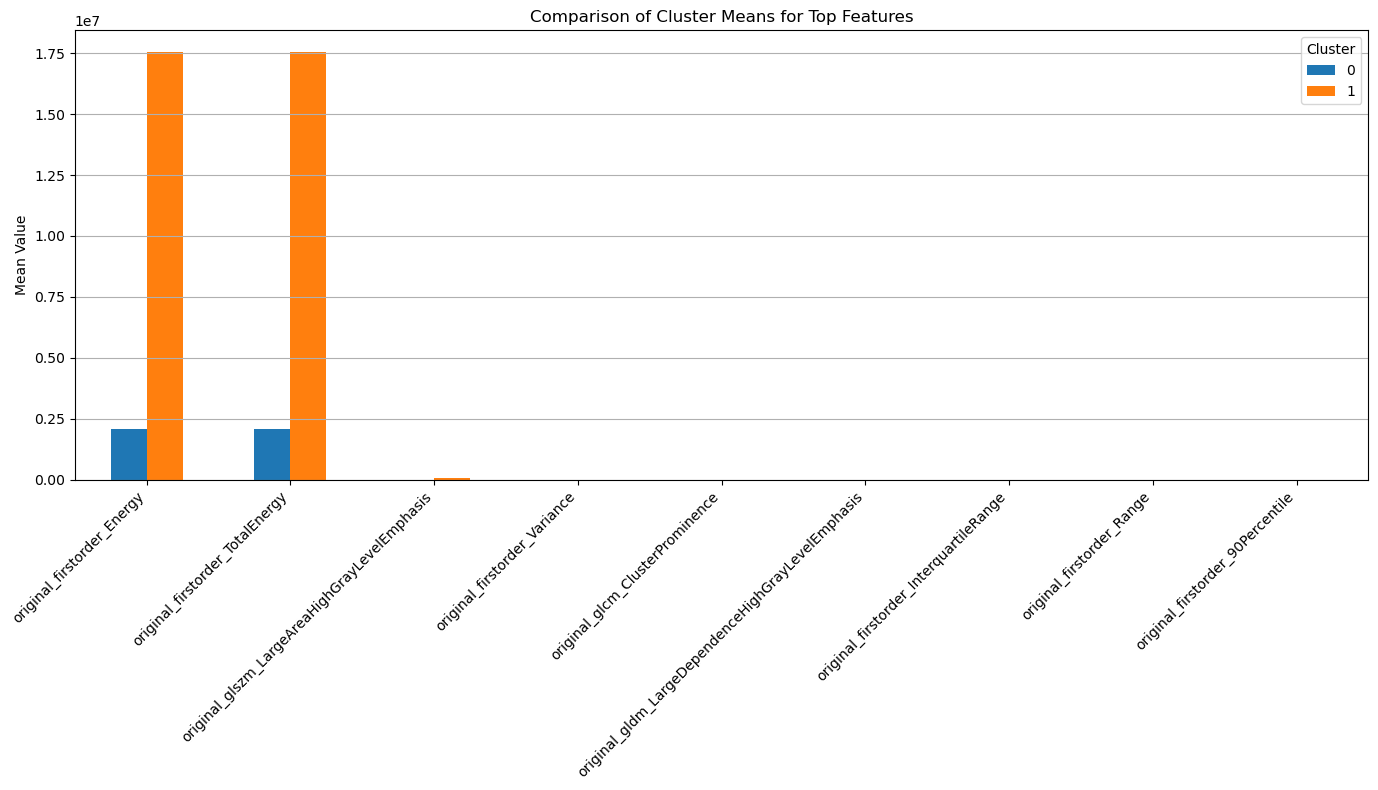

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# أهم الخصائص اللي لقينا فيها فرق كبير (اختار منها)
top_features = [
    'original_firstorder_Energy',
    'original_firstorder_TotalEnergy',
    'original_glszm_LargeAreaHighGrayLevelEmphasis',
    'original_firstorder_Variance',
    'original_glcm_ClusterProminence',
    'original_gldm_LargeDependenceHighGrayLevelEmphasis',
    'original_firstorder_InterquartileRange',
    'original_firstorder_Range',
    'original_firstorder_90Percentile'
]

# نحسب المتوسط لكل خاصية حسب الكلاستر
mean_by_cluster = df.groupby('Cluster')[top_features].mean().T

# نرسم
plt.figure(figsize=(14, 8))
mean_by_cluster.plot(kind='bar', figsize=(14, 8))
plt.title("Comparison of Cluster Means for Top Features")
plt.ylabel("Mean Value")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()


In [23]:
# 01_descriptive_stats_top_features.py
import pandas as pd
import numpy as np

DATA_PATH =df# عدّل المسار إذا لزم
OUT_CSV =r"C:\Users\DELL\Downloads\cluster_top_features.csv"

# df = pd.read_csv(DATA_PATH)
if 'Cluster' not in df.columns:
    raise ValueError("DataFrame must contain a 'Cluster' column.")

# اختر الأعمدة الرقمية فقط عدا Cluster
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('Cluster')

# متوسط ومقياس انتشار لكل Cluster
cluster_means = df.groupby('Cluster')[numeric_cols].mean()
cluster_stds = df.groupby('Cluster')[numeric_cols].std()
global_mean = df[numeric_cols].mean()

# حساب الفرق المطلق عن المتوسط العام واستخراج أهم 10 خصائص لكل Cluster
top_features_per_cluster = {}
for c in cluster_means.index:
    diffs = (cluster_means.loc[c] - global_mean).abs().sort_values(ascending=False)
    top = diffs.head(10).index.tolist()
    top_features_per_cluster[c] = top

# حفظ نتيجة إلى CSV
rows = []
for c, feats in top_features_per_cluster.items():
    rows.append({"Cluster": c, "TopFeatures": ";".join(feats)})
pd.DataFrame(rows).to_csv(OUT_CSV, index=False)

print("Top features saved to:", OUT_CSV)
for c, feats in top_features_per_cluster.items():
    print(f"\nCluster {c} top features:")
    for f in feats:
        print(" -", f)


Top features saved to: C:\Users\DELL\Downloads\cluster_top_features.csv

Cluster 0 top features:
 - original_firstorder_TotalEnergy
 - original_firstorder_Energy
 - original_glszm_LargeAreaHighGrayLevelEmphasis
 - original_firstorder_Variance
 - original_glcm_ClusterProminence
 - original_gldm_LargeDependenceHighGrayLevelEmphasis
 - original_glszm_LargeAreaEmphasis
 - original_glszm_ZoneVariance
 - original_glrlm_LongRunHighGrayLevelEmphasis
 - original_gldm_GrayLevelNonUniformity

Cluster 1 top features:
 - original_firstorder_TotalEnergy
 - original_firstorder_Energy
 - original_glszm_LargeAreaHighGrayLevelEmphasis
 - original_firstorder_Variance
 - original_glcm_ClusterProminence
 - original_gldm_LargeDependenceHighGrayLevelEmphasis
 - original_glszm_LargeAreaEmphasis
 - original_glszm_ZoneVariance
 - original_glrlm_LongRunHighGrayLevelEmphasis
 - original_gldm_GrayLevelNonUniformity


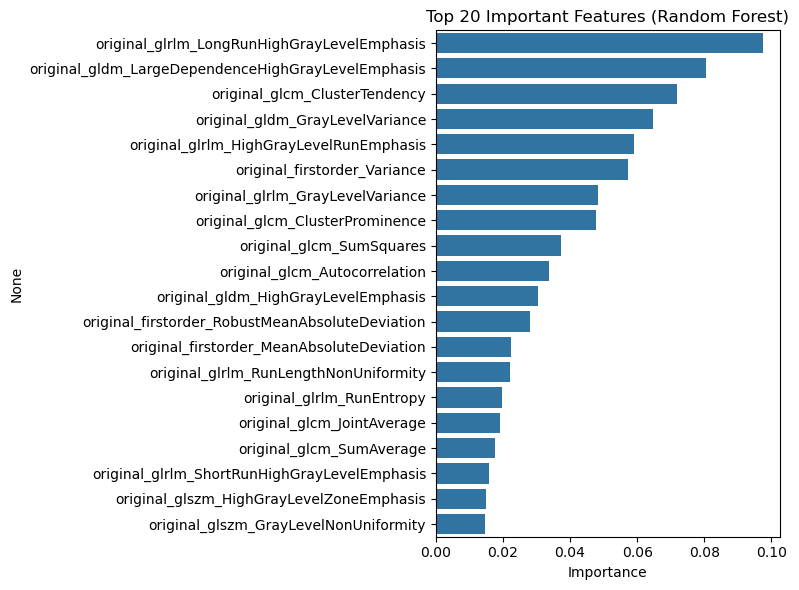

Feature importance saved to: C:\Users\DELL\Downloads\features.csv
Plot saved to: C:\Users\DELL\Downloads\feature_importance.png


In [26]:
# 02_feature_importance_rf.py
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns


OUT_PNG = r"C:\Users\DELL\Downloads\feature_importance.png"
OUT_CSV = r"C:\Users\DELL\Downloads\features.csv"


if 'Cluster' not in df.columns:
    raise ValueError("DataFrame must contain a 'Cluster' column.")

numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('Cluster')
X = df[numeric_cols].values
y = df['Cluster'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_scaled, y)

importances = pd.Series(rf.feature_importances_, index=numeric_cols).sort_values(ascending=False)
importances.head(50).to_csv(OUT_CSV)

# رسم أهم 20 ميزة
top_n = 20
plt.figure(figsize=(8, max(6, 0.25*top_n)))
sns.barplot(x=importances.head(top_n).values, y=importances.head(top_n).index)
plt.title("Top %d Important Features (Random Forest)" % top_n)
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(OUT_PNG)
plt.show()

print("Feature importance saved to:", OUT_CSV)
print("Plot saved to:", OUT_PNG)


In [15]:
# 03_shap_analysis.py
import pandas as pd
import numpy as np
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# DATA_PATH = "radiomics_clusters.csv"
OUT_PNG = r"C:\Users\DELL\Downloads\shap_summary.png"

# df = pd.read_csv(DATA_PATH)
if 'Cluster' not in df.columns:
    raise ValueError("DataFrame must contain a 'Cluster' column.")
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('Cluster')
X = df[numeric_cols].values
y = df['Cluster'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# نعيد استخدام RandomForest (يمكن استبداله بنموذج محفوظ)
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_scaled, y)

explainer = shap.TreeExplainer(rf)
# shap_values: قائمة (n_classes) عناصر في حالة تصنيف متعدد
shap_values = explainer.shap_values(X_scaled)

# رسم summary — في حالة متعدد التصنيف سيظهر لكل فئة؛ shap.summary_plot يتعامل مع هذا
plt.figure()
if isinstance(shap_values, list):
    # نرسم الملخص للفئة الأولى كتقريب (أو يمكنك رسم كل فئة منفصلة)
    shap.summary_plot(shap_values, pd.DataFrame(X_scaled, columns=numeric_cols), show=False)
else:
    shap.summary_plot(shap_values, pd.DataFrame(X_scaled, columns=numeric_cols), show=False)

plt.title("SHAP Summary")
plt.tight_layout()
plt.savefig(OUT_PNG)
plt.close()

print("SHAP summary saved to:", OUT_PNG)


SHAP summary saved to: C:\Users\DELL\Downloads\shap_summary.png


<Figure size 640x480 with 0 Axes>

 ####use pca to dimension reduction and show the distrubition to every class

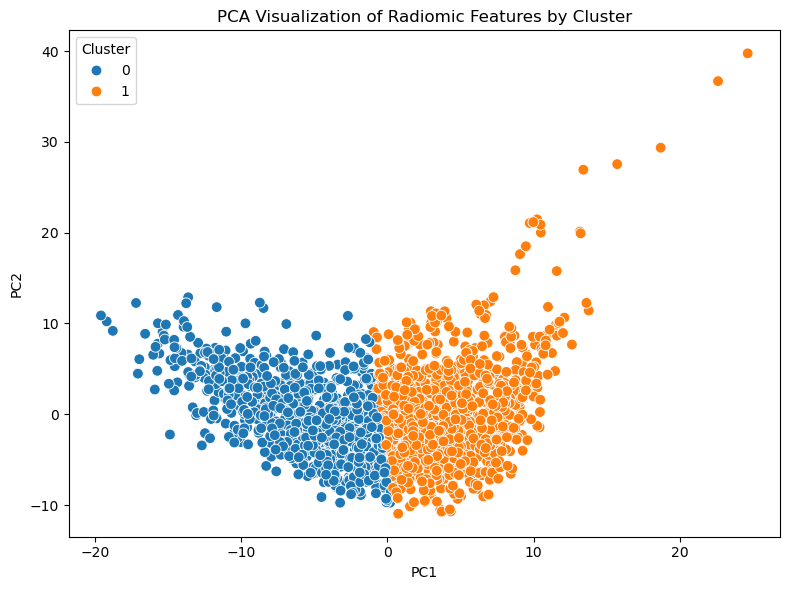

PCA plot saved to: C:\Users\DELL\Downloads\pca_clusters.png


In [27]:
# 04_pca_visualization.py
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# DATA_PATH =/ "radiomics_clusters.csv"
OUT_PNG = r"C:\Users\DELL\Downloads\pca_clusters.png"

# df = pd.read_csv(DATA_PATH)
if 'Cluster' not in df.columns:
    raise ValueError("DataFrame must contain a 'Cluster' column.")

numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('Cluster')
X = df[numeric_cols].values
y = df['Cluster'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=['PC1','PC2'])
df_pca['Cluster'] = y

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Cluster', palette='tab10', s=60)
plt.title('PCA Visualization of Radiomic Features by Cluster')
plt.tight_layout()
plt.savefig(OUT_PNG)
plt.show()

print("PCA plot saved to:", OUT_PNG)


In [28]:
# 06_auto_interpretation_text.py
import pandas as pd
import numpy as np

# DATA_PATH = "radiomics_clusters.csv"
OUT_TXT = "cluster_interpretations.txt"

# df = pd.read_csv(DATA_PATH)
if 'Cluster' not in df.columns:
    raise ValueError("DataFrame must contain a 'Cluster' column.")

numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('Cluster')
cluster_means = df.groupby('Cluster')[numeric_cols].mean()
global_mean = df[numeric_cols].mean()

def interpret_features(top_features):
    text = []
    # قواعد تفسير بسيطة (قابلة للتوسيع)
    if any("Energy" in f for f in top_features):
        text.append("High Energy → strong calcification (possible dehydration or metabolic calcium).")
    if any("Entropy" in f for f in top_features):
        text.append("High Entropy → heterogeneous internal texture (possible mixed composition or infection).")
    if any("Variance" in f for f in top_features):
        text.append("High Variance → irregular density → progressive or layered deposition.")
    if any("Homogeneity" in f for f in top_features):
        text.append("High Homogeneity → uniform composition (possible uric acid or cystine).")
    if any("Surface" in f or "Shape" in f for f in top_features):
        text.append("Irregular shape / large surface area → may be associated with infection-related stones (struvite).")
    if not text:
        text.append("Dominated by features that need deeper clinical correlation.")
    return " ".join(text)

interpretations = {}
for c in cluster_means.index:
    diffs = (cluster_means.loc[c] - global_mean).abs().sort_values(ascending=False)
    top = diffs.head(10).index.tolist()
    interpretations[c] = {
        "top_features": top,
        "interpretation": interpret_features(top)
    }

with open(OUT_TXT, "w", encoding="utf-8") as f:
    for c, v in interpretations.items():
        f.write(f"Cluster {c}\n")
        f.write("Top features: " + ", ".join(v['top_features']) + "\n")
        f.write("Interpretation: " + v['interpretation'] + "\n")
        f.write("\n")

print("Interpretations saved to:", OUT_TXT)
for c, v in interpretations.items():
    print(f"\nCluster {c}:")
    print("Top features:", v['top_features'])
    print("Interpretation:", v['interpretation'])


Interpretations saved to: cluster_interpretations.txt

Cluster 0:
Top features: ['original_firstorder_TotalEnergy', 'original_firstorder_Energy', 'original_glszm_LargeAreaHighGrayLevelEmphasis', 'original_firstorder_Variance', 'original_glcm_ClusterProminence', 'original_gldm_LargeDependenceHighGrayLevelEmphasis', 'original_glszm_LargeAreaEmphasis', 'original_glszm_ZoneVariance', 'original_glrlm_LongRunHighGrayLevelEmphasis', 'original_gldm_GrayLevelNonUniformity']
Interpretation: High Energy → strong calcification (possible dehydration or metabolic calcium). High Variance → irregular density → progressive or layered deposition.

Cluster 1:
Top features: ['original_firstorder_TotalEnergy', 'original_firstorder_Energy', 'original_glszm_LargeAreaHighGrayLevelEmphasis', 'original_firstorder_Variance', 'original_glcm_ClusterProminence', 'original_gldm_LargeDependenceHighGrayLevelEmphasis', 'original_glszm_LargeAreaEmphasis', 'original_glszm_ZoneVariance', 'original_glrlm_LongRunHighGrayLev

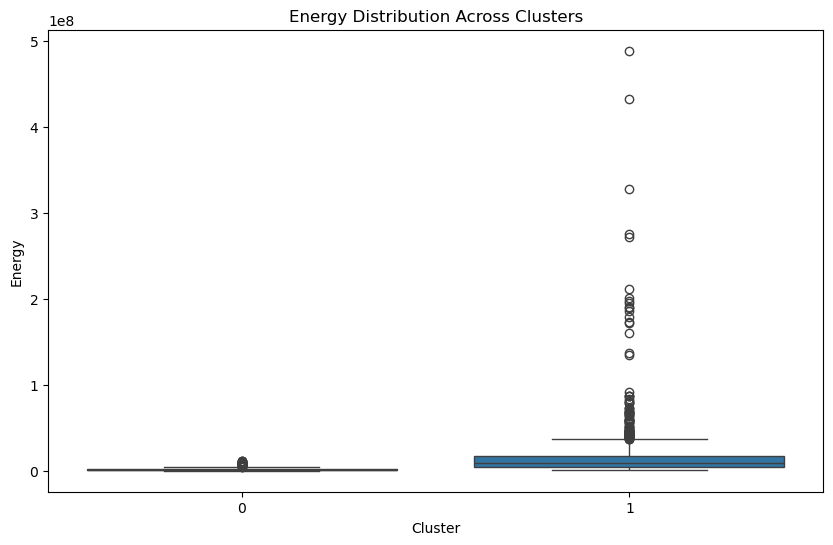

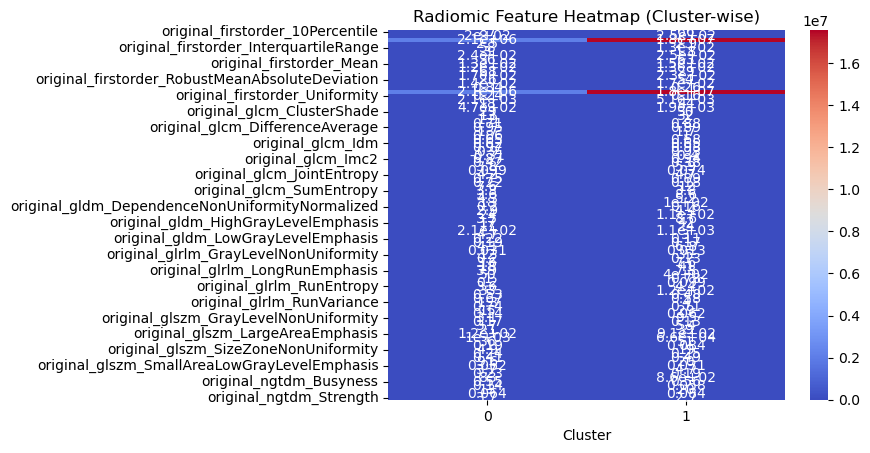

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# افترض أن لديك DataFrame باسم df_features يحوي الأعمدة radiomic + cluster
plt.figure(figsize=(10,6))
sns.boxplot(x='Cluster', y='original_firstorder_Energy', data=df)
plt.title("Energy Distribution Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Energy")
plt.show()

sns.heatmap(df.groupby('Cluster').mean().T, cmap='coolwarm', annot=True)
plt.title("Radiomic Feature Heatmap (Cluster-wise)")
plt.show()


In [21]:
print(df.columns)

Index(['original_firstorder_10Percentile', 'original_firstorder_90Percentile',
       'original_firstorder_Energy', 'original_firstorder_Entropy',
       'original_firstorder_InterquartileRange',
       'original_firstorder_Kurtosis', 'original_firstorder_Maximum',
       'original_firstorder_MeanAbsoluteDeviation', 'original_firstorder_Mean',
       'original_firstorder_Median', 'original_firstorder_Minimum',
       'original_firstorder_Range',
       'original_firstorder_RobustMeanAbsoluteDeviation',
       'original_firstorder_RootMeanSquared', 'original_firstorder_Skewness',
       'original_firstorder_TotalEnergy', 'original_firstorder_Uniformity',
       'original_firstorder_Variance', 'original_glcm_Autocorrelation',
       'original_glcm_ClusterProminence', 'original_glcm_ClusterShade',
       'original_glcm_ClusterTendency', 'original_glcm_Contrast',
       'original_glcm_Correlation', 'original_glcm_DifferenceAverage',
       'original_glcm_DifferenceEntropy', 'original_glcm_

In [12]:
import os
import cv2
import numpy as np
import pandas as pd
import torch
from ultralytics import YOLO
from radiomics import featureextractor
import SimpleITK as sitk
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image as RLImage, Table, TableStyle
from reportlab.lib.styles import getSampleStyleSheet

# ========= 1️⃣ تحميل نموذج YOLO =========
model = YOLO(r'F:\new\best (3).pt')
model.to('cpu')

# ========= 2️⃣ إعداد PyRadiomics =========
settings = {
    "binWidth": 25,
    "resampledPixelSpacing": None,
    "interpolator": "sitkBSpline",
    "enableCExtensions": True
}
extractor = featureextractor.RadiomicsFeatureExtractor()
extractor.disableAllFeatures()
extractor.enableFeatureClassByName('firstorder')
extractor.enableFeatureClassByName('glcm')
extractor.enableFeatureClassByName('glrlm')
extractor.enableFeatureClassByName('glszm')
extractor.enableFeatureClassByName('shape2D')

# ========= 3️⃣ دالة التفسير =========
def interpret_cluster(cluster_id):
    if cluster_id == 0:
        return {
            "Energy Level": "Low",
            "Texture Pattern": "Irregular / soft texture",
            "Possible Stone Type": "Uric acid / Struvite (soft or infection-related)",
            "Likely Cause": "Infection or metabolic imbalance",
            "Clinical Interpretation": (
                "These stones are usually soft and less calcified. "
                "They may respond to medical therapy or antibiotics."
            )
        }
    elif cluster_id == 1:
        return {
            "Energy Level": "High",
            "Texture Pattern": "Dense, homogeneous",
            "Possible Stone Type": "Calcium oxalate / Calcium phosphate (calcified)",
            "Likely Cause": "Dehydration, hypercalciuria, metabolic issues",
            "Clinical Interpretation": (
                "Highly calcified stones that are hard and often need lithotripsy. "
                "Recommend metabolic workup for prevention."
            )
        }
    else:
        return {
            "Energy Level": "Unknown",
            "Texture Pattern": "N/A",
            "Possible Stone Type": "Unclassified",
            "Likely Cause": "Insufficient data",
            "Clinical Interpretation": "No reliable pattern detected for this cluster."
        }

# ========= 4️⃣ إدخال الصورة =========
image_path = r"F:\new\archive (1)\alldata\1-3-46-670589-33-1-63703718086120120200001-5487554579919763006_png_jpg.rf.9fd67251e99a47dbe83a5db6efe6c016.jpg"
if image is None:
    raise ValueError("❌ لم يتم العثور على الصورة أو مسارها غير صحيح.")

print("🔍 جاري اكتشاف المناطق...")
results = model(image)
feature_list = []
colors_map = [(0, 255, 0), (255, 0, 0)]  # أخضر وأزرق للكلاستر

for result in results:
    boxes = result.boxes
    print(f"✅ تم اكتشاف {len(boxes)} مناطق ROI")
    for box in boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf = float(box.conf[0])
        if conf > 0.5:
            mask = np.zeros_like(image[:, :, 0], dtype=np.uint8)
            mask[y1:y2, x1:x2] = 1
            roi = image.copy()
            roi[mask == 0] = 0

            roi_sitk = sitk.GetImageFromArray(cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY))
            mask_sitk = sitk.GetImageFromArray(mask)
            try:
                features = extractor.execute(roi_sitk, mask_sitk)
                feature_dict = {'ROI': f"{x1}_{y1}_{x2}_{y2}"}
                for k, v in features.items():
                    if "original" in k:
                        feature_dict[k] = v
                feature_list.append(feature_dict)
                print(f"🧩 تم استخراج الخصائص من ROI ({x1},{y1},{x2},{y2})")
            except Exception as e:
                print(f"⚠️ خطأ في استخراج الخصائص: {e}")

# ========= 5️⃣ تحليل Radiomics بالـ KMeans =========
if not feature_list:
    print("❌ لا توجد مناطق مناسبة.")
else:
    df = pd.DataFrame(feature_list)
    df = df.loc[:, ~df.columns.str.startswith('diagnostics_')]
    df_numeric = df.select_dtypes(include=[np.number]).dropna(axis=1)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_numeric)

    kmeans = KMeans(n_clusters=2, random_state=42)
    clusters = kmeans.fit_predict(X_scaled)
    df['Cluster'] = clusters

    print("\n📊 أول 5 صفوف من البيانات:")
    print(df.head())

    # ========= 6️⃣ تلوين الـ ROIs حسب الكلاستر =========
    for i, row in df.iterrows():
        coords = row['ROI'].split('_')
        x1, y1, x2, y2 = map(int, coords)
        cluster_id = int(row['Cluster'])
        color = colors_map[cluster_id % len(colors_map)]
        cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)
        cv2.putText(image, f"C{cluster_id}", (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
    
#      مسار حفظ الصورة 
    image_output=r"C:\Users\DELL\Downloads\radiomcis"  
    out_image_path = os.path.splitext( image_output)[0] + "_clustered.jpg"
    cv2.imwrite(out_image_path, image)
    print(f"🖼️ تم حفظ الصورة النهائية: {out_image_path}")

    # ========= 7️⃣ إنشاء تقرير PDF =========
    #  مسار حفظ التقرير 
    report_out=r"C:\Users\DELL\Downloads\radiomcis"   
    report_path = os.path.splitext( report_out)[0] + "_report.pdf"
    doc = SimpleDocTemplate(report_path, pagesize=A4)
    styles = getSampleStyleSheet()
    elements = []

    elements.append(Paragraph("<b>Radiomics Analysis Report</b>", styles['Title']))
    elements.append(Spacer(1, 12))
    elements.append(Paragraph(f"📁 File: {os.path.basename(image_path)}", styles['Normal']))
    elements.append(Paragraph(f"🔢 Total ROIs: {len(df)}", styles['Normal']))
    elements.append(Spacer(1, 12))

    # إدراج الصورة الملونة
    elements.append(RLImage(out_image_path, width=400, height=300))
    elements.append(Spacer(1, 12))

    # تقرير لكل ROI
    for i, row in df.iterrows():
        cluster_id = int(row['Cluster'])
        interp = interpret_cluster(cluster_id)
        elements.append(Paragraph(f"<b>ROI {i+1}</b> (Cluster {cluster_id})", styles['Heading3']))

        table_data = [[k, v] for k, v in interp.items()]
        t = Table(table_data, colWidths=[150, 350])
        t.setStyle(TableStyle([
            ('BACKGROUND', (0, 0), (-1, 0), colors.lightgrey),
            ('GRID', (0, 0), (-1, -1), 0.5, colors.black),
            ('FONT', (0, 0), (-1, -1), 'Helvetica', 10)
        ]))
        elements.append(t)
        elements.append(Spacer(1, 12))

    doc.build(elements)
    print(f"✅ تم إنشاء تقرير PDF: {report_path}")


🔍 جاري اكتشاف المناطق...

0: 544x640 2 Tas_Vars, 990.2ms
Speed: 76.2ms preprocess, 990.2ms inference, 1.3ms postprocess per image at shape (1, 3, 544, 640)


GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated
GLCM is symmetrical, therefore Sum Average = 2 * Joint Average, only 1 needs to be calculated


✅ تم اكتشاف 2 مناطق ROI
🧩 تم استخراج الخصائص من ROI (129,201,151,222)
🧩 تم استخراج الخصائص من ROI (104,225,113,233)

📊 أول 5 صفوف من البيانات:
               ROI  original_shape2D_Elongation  \
0  129_201_151_222                     0.954449   
1  104_225_113_233                     0.887412   

   original_shape2D_MajorAxisLength original_shape2D_MaximumDiameter  \
0                         25.377155               29.732137494637012   
1                         10.327956                11.40175425099138   

  original_shape2D_MeshSurface  original_shape2D_MinorAxisLength  \
0                        461.5                         24.221203   
1                         71.5                          9.165151   

  original_shape2D_Perimeter original_shape2D_PerimeterSurfaceRatio  \
0          84.82842712474618                     0.1838102429571965   
1          32.82842712474619                    0.45913884090554113   

   original_shape2D_PixelSurface  original_shape2D_Sphericity  ... 